In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.path as mpath
import matplotlib.patches as patches
from matplotlib.lines import Line2D
import os
import sys
import pickle
import math
import matplotlib

path = os.getcwd().split(os.sep + 'GUI')[0]
if path not in sys.path:
    print("not here")
    sys.path.append(path)

import neurolib.dashboard.data as data
from neurolib.models.aln import ALNModel
import neurolib.dashboard.layout as layout
import neurolib.dashboard.functions as functions
from neurolib.utils import plotFunctions as plotFunc
from neurolib.utils import func_optimize as fo
from neurolib.utils import costFunctions as cost


# This will reload all imports as soon as the code changes
%load_ext autoreload
%autoreload 2    

not here


In [42]:
readpath = '..' + os.sep

with open(readpath + os.sep + 'bi.pickle','rb') as file:
    load_array= pickle.load(file)
ext_exc = load_array[0]
ext_inh = load_array[1]

cmap = layout.getcolormap()
darkgrey, midgrey, lightgrey, color_bi_updown, color_LC, color_bi_uposc = layout.getcolors()
exc_red = cmap(3)
inh_blue=cmap(0)
green = cmap(2)

aln = ALNModel()
data.set_parameters(aln)
state_vars = aln.state_vars

facecolor_ = '#EAEAEA'
facecolor_ = 'white'

In [10]:
readpath = os.path.join(os.getcwd().split('plots_paper')[0], 'data_final' + os.sep + 'control_tradeoff.pickle')
savepath = os.path.join(os.getcwd().split('neurolib')[0], 'writing' + os.sep + 'paper1' + os.sep + 'concept' + os.sep + 'images')

In [11]:
##############################################################
def setinit(init_vars_, model):
    state_vars = model.state_vars
    init_vars = model.init_vars
    for iv in range(len(init_vars)):
        for sv in range(len(state_vars)):
            if state_vars[sv] in init_vars[iv]:
                #print("set init vars ", )
                if model.params[init_vars[iv]].ndim == 2:
                    model.params[init_vars[iv]][0,:] = init_vars_[sv]
                else:
                    model.params[init_vars[iv]][0] = init_vars_[sv]

def readcase(readpath):
    
    control_data = data.read_control_tradeoff(readpath, '')
    opt_control = control_data[0]
    opt_state = control_data[1]
    opt_cost = control_data[2]

    return opt_control, opt_state, opt_cost

In [16]:
opt_control, opt_state, opt_cost = readcase(readpath)
print(len(opt_control), len(opt_cost))

case =  /home/lena/Promotion/neurolib/GUI/current/gui/data_final/control_tradeoff.pickle 
20 20


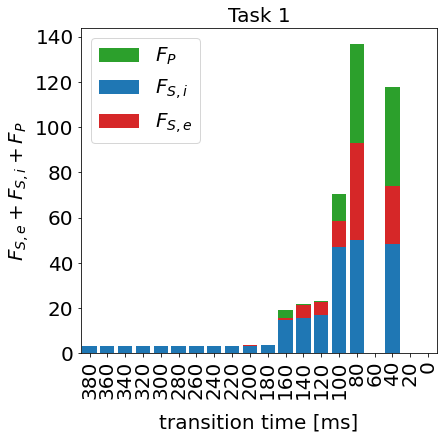

In [55]:
fig_1, ax = plt.subplots(1,1, constrained_layout=True, figsize = (6,6) )
fontsize_ = 20

trans_time = np.arange(380., -10., -20.)

x_label = ['{:.0f}'.format(tt) for tt in trans_time]

p_cost = []
s_cost_e = []
s_cost_i = []

for i in range(len(opt_cost)):
    if opt_cost[i][0][0][0] < 100:
        s_cost_i.append(opt_cost[i][2][0][1])
        s_cost_e.append(opt_cost[i][2][0][0] + s_cost_i[-1])
        p_cost.append(opt_cost[i][0][0][0] + s_cost_e[-1])
    else:
        p_cost.append(0.)
        s_cost_e.append(0.)
        s_cost_i.append(0.)

ax.bar(range(len(opt_control)), p_cost, label=r'$F_P$', color=green, zorder=1)
ax.bar(range(len(opt_control)), s_cost_i, label=r'$F_{S,i}$', color=inh_blue, zorder=3)
ax.bar(range(len(opt_control)), s_cost_e, label=r'$F_{S,e}$', color=exc_red, zorder=2)

        
ax.set_xlim(-0.5, 19.5)
#ax. set_ylim(0., 10.)
ax.legend(loc='upper left', fontsize=fontsize_)


ax.set_xlabel(r'transition time [ms]', fontsize=fontsize_, labelpad=15)
ax.set_xticks(range(len(opt_control)))
ax.set_xticklabels(x_label, rotation=90)
ax.set_ylabel(r'$F_{S,e} + F_{S,i} + F_P$', fontsize=fontsize_)

ax.tick_params(axis='x', labelsize=fontsize_)
ax.tick_params(axis='y', labelsize=fontsize_)
ax.grid(False)

ax.set_title('Task 1', fontsize=fontsize_)

#plt.savefig( os.path.join(os.getcwd(), 'tradeoff_1a.png') )
#plt.savefig( os.path.join(savepath, 'tradeoff_1a.png') )

plt.show()